# Statistical Analysis of Disciplinary Behaviour in European Football

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pickle

with open("../data/processed/team_matches.pkl", "rb") as f:
    team_matches = pickle.load(f)

In [3]:
team_matches.head()

,season,date,team,opponent,yellow_cards,red_cards,fouls_committed,fouls_received,shots,shots_opponent,shots_on_target,shots_on_target_opponent,corners,corners_opponent,goals_scored,goals_conceded,match_result,venue,team_result,league
0,2526,23/08/2025,Genoa,Lecce,2.0,0.0,16.0,13.0,5.0,7.0,2.0,0.0,3.0,7.0,0.0,0.0,D,home,D,Serie_A
1,2526,23/08/2025,Sassuolo,Napoli,3.0,1.0,17.0,17.0,7.0,13.0,2.0,4.0,1.0,2.0,0.0,2.0,A,home,L,Serie_A
2,2526,23/08/2025,Milan,Cremonese,1.0,0.0,10.0,14.0,24.0,4.0,6.0,3.0,9.0,2.0,1.0,2.0,A,home,L,Serie_A
3,2526,23/08/2025,Roma,Bologna,1.0,0.0,15.0,13.0,14.0,10.0,4.0,2.0,2.0,4.0,1.0,0.0,H,home,W,Serie_A
4,2526,24/08/2025,Cagliari,Fiorentina,4.0,0.0,18.0,14.0,14.0,4.0,6.0,1.0,3.0,2.0,1.0,1.0,D,home,D,Serie_A


## Yellow Cards per Foul: Defining the Metric

We start with a focused test case: **Serie A, season 2025/26**. Working with a single league and season first keeps the analysis concrete and the numbers interpretable. Once we have validated the approach, we will extend it to all leagues and seasons.

The first metric of interest is the ratio of yellow cards to fouls committed. This normalises for playing style: a team that fouls more will naturally receive more cards, so the raw count of yellow cards is not a fair comparison across teams. The ratio isolates the question we actually care about — *given a foul was committed, how likely was it to result in a card?*

$$\text{ycards\_per\_foul}_{i} = \frac{\text{yellow cards}_{i}}{\text{fouls committed}_{i}}$$

where $i$ indexes each match.

**Q. When computing the cards-per-foul metric, does it matter which variable goes in the denominator?**

> Both ratios carry the same information — one is the inverse of the other. The convention is to put the *exposure variable* in the denominator: the variable that represents the opportunity for the event to occur. Here, fouls is the exposure: a card can only be issued when a foul happens. A secondary practical reason is that fouls committed is far less likely to be zero than yellow cards, avoiding `inf` values in the ratio. But as we will see, zero-foul matches do occur.

In [4]:
test_season = '2526'
test_league = 'Serie_A'

test_df = team_matches[(team_matches['season'] == test_season) & (team_matches['league'] == test_league)]
test_df['ycards_per_fouls'] = test_df['yellow_cards']/test_df['fouls_committed']

Before using this ratio in any calculation, we check for two edge cases that would break downstream analysis:

- **NaN values** — produced if either yellow cards or fouls contain missing data
- **Infinite values** — produced when `fouls_committed = 0` (division by zero)

The second case is worth investigating: did any team genuinely commit zero fouls in a match? The answer turns out to be yes — and it is a good reminder that edge cases in real data are not always errors.

In [5]:
test_df['ycards_per_fouls'].isna().sum()

np.int64(0)

In [6]:
np.isinf(test_df['ycards_per_fouls']).sum()

np.int64(0)

In [7]:
team_matches[(team_matches['fouls_committed'] == 0) | (team_matches['fouls_received'] == 0)]

,season,date,team,opponent,yellow_cards,red_cards,fouls_committed,fouls_received,shots,shots_opponent,shots_on_target,shots_on_target_opponent,corners,corners_opponent,goals_scored,goals_conceded,match_result,venue,team_result,league
13577,1920,30/11/2019,Chelsea,West Ham,0.0,0.0,0.0,16.0,19.0,5.0,6.0,4.0,9.0,3.0,0.0,1.0,A,home,L,Premier_League
14166,1819,20/04/2019,Wolves,Brighton,0.0,0.0,0.0,8.0,22.0,5.0,5.0,0.0,14.0,1.0,0.0,0.0,D,home,D,Premier_League
19206,1920,30/11/2019,West Ham,Chelsea,3.0,0.0,16.0,0.0,5.0,19.0,4.0,6.0,3.0,9.0,1.0,0.0,A,away,W,Premier_League
19795,1819,20/04/2019,Brighton,Wolves,1.0,0.0,8.0,0.0,5.0,22.0,0.0,5.0,1.0,14.0,0.0,0.0,D,away,D,Premier_League
25780,1718,22/04/18,Malaga,Sociedad,4.0,0.0,16.0,0.0,4.0,14.0,3.0,2.0,5.0,3.0,2.0,0.0,H,home,W,La_Liga
31390,1718,22/04/18,Sociedad,Malaga,1.0,0.0,0.0,16.0,14.0,4.0,2.0,3.0,3.0,5.0,0.0,2.0,H,away,L,La_Liga
44374,2122,21/05/2022,Lille,Rennes,2.0,0.0,12.0,0.0,13.0,13.0,4.0,3.0,7.0,4.0,2.0,2.0,D,home,D,Ligue_1
49684,2122,21/05/2022,Rennes,Lille,2.0,0.0,0.0,12.0,13.0,13.0,3.0,4.0,4.0,7.0,2.0,2.0,D,away,D,Ligue_1


The investigation confirms that all four cases are genuine — each was verified against an external match report. Three of them are unusual but valid matches: a team committed zero fouls and the data is consistent with the official record.

The fourth — **Lille vs Rennes** — is more interesting: the source data reports zero fouls committed but a yellow card was issued. This is a genuine data inconsistency that cannot be resolved without access to the original match report. It is left in the dataset with this note, as removing it would require an arbitrary decision about which source to trust.

- [Chelsea - West Ham](https://www.espn.co.uk/football/matchstats/_/gameId/541714)
- [Wolves - Brighton](https://www.espn.co.uk/football/matchstats/_/gameId/513490)
- [Malaga - Real Sociedad](https://www.espn.co.uk/football/matchstats/_/gameId/490376) — zero fouls but one yellow card, likely for time-wasting
- [Lille - Rennes](https://www.espn.com/soccer/matchstats/_/gameId/609158) — **data inconsistency**: zero fouls reported but a yellow card issued

This finding illustrates a broader point worth stating explicitly: *data quality is not a one-time check. Anomalies surface throughout the analysis, often precisely because the analysis forces you to look at values you would not have examined otherwise.*

In [8]:
1/test_df['ycards_per_fouls'].mean()

np.float64(6.514874472416589)

## The Two Ways to Measure a Rate (and Why They Differ)

With the per-match ratio defined, the natural next step is to summarise it at team level. There are two ways to do this, and they give different answers.

**Approach 1 — Mean of per-match ratios**

Compute the ratio for each match, then average across all matches played by the team:

$$\bar{r} = \frac{1}{n} \sum_{i=1}^{n} \frac{\text{yellow cards}_i}{\text{fouls}_i}$$

**Approach 2 — Ratio of season totals**

Sum yellow cards and fouls across all matches, then divide:

$$R = \frac{\displaystyle\sum_{i=1}^{n} \text{yellow cards}_i}{\displaystyle\sum_{i=1}^{n} \text{fouls}_i}$$

In [27]:
k = (test_df
     .groupby('team')
     .agg(
         sum_fouls =  ('fouls_committed', 'sum'),
         sum_ycards = ('yellow_cards', 'sum'),
         total_played = ('team', 'size'),
         mean_ycards = ('yellow_cards', 'mean'),
         mean_ycards_per_fouls = ('ycards_per_fouls', 'mean')
         ).reset_index()
         )

k['ycards_per_fouls'] = k['sum_ycards']/k['sum_fouls']
k.sort_values(by = ['ycards_per_fouls', 'team'])

,team,sum_fouls,sum_ycards,total_played,mean_ycards,mean_ycards_per_fouls,ycards_per_fouls
8,Juventus,370.0,36.0,30,1.200000,0.097012,0.097297
12,Napoli,361.0,42.0,30,1.400000,0.119034,0.116343
7,Inter,406.0,50.0,30,1.666667,0.130098,0.123153
15,Roma,437.0,57.0,30,1.900000,0.129059,0.130435
10,Lecce,380.0,51.0,30,1.700000,0.142221,0.134211
17,Torino,429.0,59.0,30,1.966667,0.139115,0.137529
0,Atalanta,338.0,47.0,30,1.566667,0.152437,0.139053
18,Udinese,424.0,59.0,30,1.966667,0.153804,0.139151
1,Bologna,409.0,57.0,30,1.900000,0.164417,0.139364
6,Genoa,387.0,55.0,30,1.833333,0.139173,0.142119


### Why the two values differ

The ratio of totals ($R$) is mathematically equivalent to a **weighted mean** of the per-match ratios, where each match is weighted by its share of the total fouls:

$$R = \sum_{i=1}^{n} w_i \cdot \frac{\text{yellow cards}_i}{\text{fouls}_i}, \qquad w_i = \frac{\text{fouls}_i}{\displaystyle\sum_{j=1}^{n} \text{fouls}_j}$$

The simple mean $\bar{r}$ weights every match equally — a match with 2 fouls counts the same as a match with 20 fouls. The ratio of totals $R$ weights every **foul** equally — a match with 20 fouls has ten times the influence of a match with 2 fouls.

### Which one to use?

For this analysis, the **ratio of totals** is the correct choice. The question we are asking is: *across a season, for every foul this team committed, how often was a card issued?* The natural unit of exposure is the foul, not the match. Weighting by fouls is not a distortion — it is the correct accounting.

The unweighted mean over-represents low-foul matches. A game where a team commits 2 fouls and receives 1 card gives a ratio of $0.5$, which would carry the same weight as a game with 18 fouls and 2 cards (ratio $\approx 0.11$), despite the first match containing far less information about the team's typical disciplinary pattern.

This distinction has a name in statistics. In epidemiology, the ratio of totals is called the **crude rate** or **pooled rate** — the standard approach when measuring event frequency relative to an exposure variable (Rothman et al., 2008). The unweighted average is sometimes called the **naive rate** precisely because it ignores differences in exposure.

### A note for later — Simpson's Paradox

The gap between the two rates is not just a technical detail. In some situations, a pattern visible at the aggregate level can reverse or disappear when broken down into subgroups — and vice versa. This is known as [**Simpson's Paradox**](https://en.wikipedia.org/wiki/Simpson's_paradox) (Simpson, 1951), and it is a genuine risk when combining data across seasons or leagues. We will return to this when we extend the analysis beyond a single season.

---

**References**

- [Rothman, K.J., Greenland, S., Lash, T.L. (2008). *Modern Epidemiology*](https://shop.lww.com/Modern-Epidemiology/p/9781451193282), 3rd ed. Lippincott Williams & Wilkins — standard reference on rates, crude rates, and adjusted rates
- Simpson, E.H. (1951). ["The interpretation of interaction in contingency tables."](https://math.bme.hu/~marib/bsmeur/simpson.pdf) *Journal of the Royal Statistical Society, Series B*, 13, 238–241
- [Sumpter, D. (2016). *    *.](https://www.amazon.co.uk/Soccermatics-Mathematical-Adventures-Beautiful-Bloomsbury/dp/1472924126) Bloomsbury — accessible treatment of mathematical rates applied to football
- [Wheelan, C. (2013). *Naked Statistics*](https://wwnorton.com/books/naked-statistics/). Norton — lay introduction to means, rates, and why aggregation can mislead

---

## Building a Hypothesis Test from First Principles

We now ask the question formally: **is Juventus's yellow card rate per foul statistically different from the rest of the league?**

We noticed, in fact, that Juventus has the lowest value for yellow cards received for faul committed, and so it looks fair to ask if this value is extreem or not.

The approach is deliberately incremental. We start from the simplest possible model, state its assumptions explicitly, check them against the data, and improve where the assumptions fail. This is not the fastest path to an answer but it is the most honest one and also can be useful to explain better the theory and the art of data science that is behind this kind of analysis.

### The model: each foul is a Bernoulli trial

We start with the simplest probabilistic model that makes the question precise.

A **Bernoulli trial** is a single experiment with exactly two outcomes: success (1) or failure (0), each occurring with a fixed probability. Here:

- **One trial** = one foul committed
- **Success** = a yellow card is issued for that foul
- **Probability of success** = $p$, the underlying rate at which fouls result in cards

Under this model, a team that commits $n$ fouls in a season and receives $k$ yellow cards has an observed rate $\hat{p} = k/n$, and the total number of cards follows a **Binomial distribution**:

$$K \sim \text{Binomial}(n,\ p)$$

**Assumptions — stated before any test is run:**

1. Each foul is an independent trial: the outcome of one foul does not affect the probability of the next
2. The probability $p$ is constant across all fouls — regardless of match, referee, scoreline, or opponent
3. The league reference rate $p_0$ is a fixed, known value against which we compare the team

These are strong assumptions. We state them now — not as caveats at the end — because a good statistical analysis names its model before presenting its results. We will check each one against the data after running the test.

### The reference rate $p_0$

The hypothesis test compares Juventus's observed rate $\hat{p}$ against a reference value $p_0$ — the rate we would expect if Juventus were an unremarkable team in this league.

The natural candidate for $p_0$ is the league crude rate, in this case the total number of yellow cards received divided the total number of fouls committed. But which matches to include?

If we include Juventus in the calculation, then $p_0$ is partly determined by the very data we are testing. Juventus's own 36 cards and 370 fouls pull the league average toward their value, making the reference smaller than it would be without them. The test would be comparing Juventus against a benchmark that Juventus itself has shifted which - a mild but genuine circularity.

The correct approach is to compute $p_0$ from the **rest of the league only**, excluding Juventus entirely:

$$p_0 = \frac{\sum_{i \notin \text{Juventus}} \text{yellow cards}_i}{\sum_{i \notin \text{Juventus}} \text{fouls}_i}$$

This gives us a reference rate that is independent of the team being tested — a requirement for a valid one-sample test.

In [ ]:
team_name = 'Juventus'

team_df  = test_df[test_df['team'] == team_name]
rest_df  = test_df[test_df['team'] != team_name]

n  = int(team_df['fouls_committed'].sum())   # number of trials
k  = int(team_df['yellow_cards'].sum())      # number of successes
p_hat = k / n                                # observed rate

p0 = rest_df['yellow_cards'].sum() / rest_df['fouls_committed'].sum()  # reference rate

print(f"Team                    : {team_name}")
print(f"Fouls committed (n)     : {n}")
print(f"Yellow cards (k)        : {k}")
print(f"Observed rate  p̂        : {p_hat:.4f}")
print(f"Reference rate p₀       : {p0:.4f}")
print(f"Difference  p̂ - p₀      : {p_hat - p0:+.4f}")

### One-sample proportion test (z-test)

Under $H_0$, the number of yellow cards $K$ follows $\text{Binomial}(n, p_0)$. The exact distribution is known, but for large $n$ the **Central Limit Theorem** tells us that the sample proportion $\hat{p} = K/n$ is approximately normally distributed:

$$\hat{p} \approx \mathcal{N}\!\left(p_0,\ \frac{p_0\,(1-p_0)}{n}\right)$$

This allows us to construct a standard test statistic:

$$z = \frac{\hat{p} - p_0}{\sqrt{p_0\,(1-p_0)\,/\,n}}$$

Under $H_0$, $z$ follows a standard normal distribution $\mathcal{N}(0, 1)$. Large values of $|z|$ indicate that the observed rate is far from what the null predicts.

**Before applying this approximation, we must verify the conditions.** The normal approximation to the binomial is reliable when both:

$$n \cdot p_0 > 10 \qquad \text{and} \qquad n \cdot (1 - p_0) > 10$$

With $n = 370$ and $p_0 = 0.1486$:

$$n \cdot p_0 \approx 55 \qquad \checkmark \qquad n \cdot (1-p_0) \approx 315 \qquad \checkmark$$

The conditions are comfortably satisfied. The approximation is valid here.

In [29]:
from scipy import stats

se = np.sqrt(p0 * (1 - p0) / n)   # standard error under H₀
z  = (p_hat - p0) / se             # test statistic
p_value_z = 2 * stats.norm.cdf(z)  # two-tailed p-value (z is negative, so cdf gives left tail)

print(f"Standard error (SE)     : {se:.4f}")
print(f"z-statistic             : {z:.4f}")
print(f"p-value (two-tailed)    : {p_value_z:.4f}")

Standard error (SE)     : 0.0185
z-statistic             : -2.7741
p-value (two-tailed)    : 0.0055


### Exact binomial test

The z-test relies on the normal approximation to the binomial. The approximation is valid here — we verified the conditions — but it is still an approximation. The exact p-value can be computed directly from the binomial distribution, without any approximation at all.

The **exact binomial test** asks: if $K \sim \text{Binomial}(n, p_0)$, what is the probability of observing a result at least as extreme as $k = 36$?

For a two-tailed test this means: the probability of $K \leq 36$ (Juventus's side) plus the probability of the symmetric tail on the other side.

If the two tests agree, the normal approximation is validated. If they disagree, we trust the exact result.

In [ ]:
result_binom = stats.binomtest(k, n, p0, alternative='two-sided')

print(f"Exact binomial p-value  : {result_binom.pvalue:.4f}")
print(f"z-test p-value          : {p_value_z:.4f}")
print(f"Difference              : {abs(result_binom.pvalue - p_value_z):.4f}")

The two p-values differ by 0.0012 — negligible in practice. Both place the result well below the conventional $\alpha = 0.05$ threshold, and the exact binomial confirms that the normal approximation did not distort the conclusion.

We now have our first formal result: **under the Bernoulli model, Juventus's yellow card rate is statistically different from the rest of Serie A 2025/26** ($p \approx 0.004$, exact binomial).

But this result is only as reliable as its assumptions. Before interpreting it, we check them.

### Checking the assumptions

We stated three assumptions before running the test. A result that depends on assumptions we cannot defend is not a reliable result — it is an artifact of the model. We now examine each assumption in turn, using the data itself as evidence.

The goal is not to invalidate the test. It is to understand *how much* we can trust it, and *where* it might be misleading.

**Assumption 1 — constant $p$**

The Bernoulli model assumes that the probability of a card given a foul is the same for every foul, in every match, across the entire season. If $p$ varies — say, because some referees are stricter than others, or because a team's disciplinary behaviour shifts across the season — then the binomial model is misspecified.

We cannot observe $p$ directly for individual fouls, but we can look at the per-match rate $\hat{p}_j = k_j / n_j$ over time. If $p$ is truly constant, the per-match rates should scatter randomly around the season average with no systematic trend.

We plot Juventus's per-match rate across matchdays, ordered by date.

In [ ]:
juve_by_match = team_df.sort_values('date').reset_index(drop=True)
juve_by_match['matchday'] = juve_by_match.index + 1

fig, ax = plt.subplots(figsize=(12, 4))

ax.scatter(juve_by_match['matchday'], juve_by_match['ycards_per_fouls'],
           color='crimson', alpha=0.7, zorder=3, label='Per-match rate')
ax.axhline(p_hat, color='crimson', linestyle='--', linewidth=1.2,
           label=f'Season rate p̂ = {p_hat:.3f}')
ax.axhline(p0, color='steelblue', linestyle='--', linewidth=1.2,
           label=f'Reference rate p₀ = {p0:.3f}')

ax.set_xlabel('Matchday')
ax.set_ylabel('Yellow cards / fouls committed')
ax.set_title(f'{team_name} — Per-match yellow card rate, Serie A {test_season}',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Is the variation too large? Checking for overdispersion**

Visual scatter alone is not enough to conclude that $p$ is non-constant — as discussed above, some match-to-match variation is expected even under a perfectly constant-$p$ model. To quantify this, we use a formal **overdispersion check**.

Under $\text{Binomial}(n_j, p)$, the expected number of cards in match $j$ is $\mu_j = n_j \hat{p}$, and the variance is $\sigma^2_j = n_j \hat{p}(1-\hat{p})$. If the model is correct, the squared deviations $(k_j - \mu_j)^2$ should be proportional to $\sigma^2_j$ on average. The **Pearson $\chi^2$ statistic** aggregates these deviations across all $m$ matches:

$$\chi^2 = \sum_{j=1}^{m} \frac{(k_j - n_j\hat{p})^2}{n_j\hat{p}(1-\hat{p})}$$

Under the binomial model, this follows approximately a $\chi^2$ distribution with $m - 1$ degrees of freedom (one parameter $\hat{p}$ was estimated from the data).

The key diagnostic is the **dispersion ratio**:

$$\phi = \frac{\chi^2}{m - 1}$$

- $\phi \approx 1$: variance matches binomial expectation — assumption is plausible  
- $\phi \gg 1$: **overdispersion** — more match-to-match variability than the binomial predicts; $p$ may not be constant  
- $\phi \ll 1$: underdispersion — less variability than expected (rare in practice)

In [ ]:
m = len(juve_by_match)

expected  = juve_by_match['fouls_committed'] * p_hat
observed  = juve_by_match['yellow_cards']

chi2_stat = ((observed - expected) ** 2 / (juve_by_match['fouls_committed'] * p_hat * (1 - p_hat))).sum()
dof       = m - 1
phi       = chi2_stat / dof
p_chi2    = 1 - stats.chi2.cdf(chi2_stat, dof)

print(f"Matches (m)             : {m}")
print(f"Pearson χ²              : {chi2_stat:.3f}")
print(f"Degrees of freedom      : {dof}")
print(f"Dispersion ratio φ      : {phi:.3f}")
print(f"p-value (χ² test)       : {p_chi2:.4f}")

The dispersion ratio $\phi = 0.906$ is close to 1 and the $\chi^2$ test returns $p = 0.61$ — we find no evidence against the binomial variance model. The match-to-match scatter we observed in the plot is entirely consistent with what a constant-$p$ binomial process would produce at these sample sizes.

Two things to note:

- The result does **not prove** that $p$ is constant. It means the data is *compatible* with constant $p$ in terms of variance — a weaker statement. Other forms of non-constancy (e.g. systematic trends, referee clustering) would not necessarily show up as overdispersion.
- With only $m = 30$ matches, the $\chi^2$ test has limited power. A moderate degree of overdispersion could exist and remain undetected.

**Verdict on Assumption 1**: no evidence of overdispersion. The binomial variance structure is plausible for this dataset.

**Assumption 2 — independence between trials**

The binomial model treats every foul as an independent draw. This assumption operates at two levels, and they require different treatment.

**Level 1 — Within-match independence (structural violation)**

Fouls within the same match share the same referee, the same two teams, and the same evolving match context. A referee who has already booked two players may apply a higher threshold for the next foul to avoid escalating the game. A team that concedes a goal may start fouling more aggressively — or more carelessly. The scoreline, the time remaining, and the crowd all influence how fouls are judged.

This is a **structural violation**: the trials are not independent by construction, and no statistical test can fix it because we do not have foul-level data — only match-level aggregates. The binomial model ignores the match as a unit entirely, pooling all 370 fouls as if they were drawn from the same independent process. They were not.

**Level 2 — Between-match independence (testable)**

A weaker form of the assumption is that match $j$'s outcome does not influence match $j+1$. This could be violated if, say, suspensions from one match alter the squad in the next, or if a pattern of strict refereeing in one week persists into the following week.

This we can test. If the per-match rates are serially correlated, the binomial model understates the true uncertainty in $\hat{p}$. We check by computing the autocorrelation of the per-match rate series at short lags.

In [34]:
rates = juve_by_match['ycards_per_fouls']

max_lags = 5
autocorrs = [rates.autocorr(lag=l) for l in range(1, max_lags + 1)]

print("Autocorrelation of per-match rates:")
print(f"{'Lag':<8} {'Autocorrelation':>16}")
print("-" * 26)
for lag, ac in enumerate(autocorrs, start=1):
    print(f"{lag:<8} {ac:>16.4f}")

Autocorrelation of per-match rates:
Lag       Autocorrelation
--------------------------
1                  0.0196
2                 -0.0394
3                 -0.0512
4                 -0.0525
5                  0.2010


All autocorrelations are small. For a series of length $m = 30$, the approximate 95% confidence band under the null of no serial correlation is $\pm 1.96/\sqrt{30} \approx \pm 0.358$. Every lag falls well within this range, including lag 5 (0.201), which is the largest but still consistent with sampling noise.

**Verdict on Assumption 2:**

- *Within-match*: structurally violated — fouls in the same match share a referee and a game context. This is a known limitation of the binomial model that cannot be resolved with this data.
- *Between-match*: no detectable serial correlation. The per-match rates behave as if they are drawn independently across matchdays.

The within-match violation is the more serious of the two. It means the effective number of independent pieces of information is smaller than 370 — the fouls are grouped into 30 clusters (matches), and within each cluster they are not fully independent. This inflates our confidence in $\hat{p}$ relative to what the binomial model claims. We will return to this when we introduce the bootstrap, which respects the match as the natural unit of observation.

**Assumption 3 — $p_0$ is a fixed, known value**

The one-sample z-test treats $p_0$ as a given constant — not as an estimate subject to its own uncertainty. In practice, $p_0$ is computed from 570 match observations (19 teams × 30 matches), which means it carries sampling error of its own.

However, the uncertainty in $p_0$ is negligible here. With 19 times as many observations as Juventus, the standard error of $p_0$ is roughly $1/\sqrt{19} \approx 23\%$ of the standard error of $\hat{p}$. Its contribution to the total uncertainty is small enough to ignore.

If the two groups were more balanced in size — say, comparing two individual teams directly — ignoring the uncertainty in $p_0$ would be inappropriate, and a **two-sample proportion test** would be the correct approach. For a one-team comparison against the rest of a league, treating $p_0$ as fixed is a reasonable approximation.

**Verdict on Assumption 3**: acceptable given the large size of the reference group.

---

**Summary of assumption checks**

| Assumption | Status | Notes |
|---|---|---|
| Constant $p$ | Plausible | No overdispersion detected ($\phi = 0.91$, $p = 0.61$) |
| Independence | Partially violated | Within-match: structural violation; between-match: no serial correlation |
| $p_0$ fixed and known | Acceptable | Reference group is 19× larger than the test group |

The within-match dependence is the main limitation of the binomial model. It means the test treats 370 fouls as 370 independent pieces of evidence, when the true information is closer to 30 independent match outcomes. This motivates a different approach — one that treats the match, not the foul, as the unit of observation.

### The bootstrap: a model-free alternative

The binomial test gave us a result, but it rests on assumptions — particularly the independence of fouls within a match — that we know are at least partially violated. We now introduce a different approach that sidesteps the distributional assumptions entirely.

**The core idea**

The binomial test asked: *if the true probability of a card per foul is $p_0$, how likely is it to observe $\hat{p}$ this far from $p_0$?* To answer this, it used a mathematical formula derived from the normal approximation.

The bootstrap asks the same question differently: *if Juventus were just a typical Serie A team, what range of season rates would we expect to see?* Instead of using a formula, it answers by **simulation directly from the data**.

The logic is simple. We have 570 matches from the other 19 teams. If Juventus is nothing special, their 30-match season is — in principle — just one possible sample of 30 matches drawn from the same population as everyone else. So we ask: what would Juventus's crude rate look like if we drew 30 random matches from the rest of the league? We do this thousands of times, and the distribution of results is our **null distribution** — the range of outcomes we would expect from an ordinary team.

If Juventus's actual rate falls deep in the tail of this distribution, it is unlikely to have arisen by chance. If it falls in the middle, the data is consistent with Juventus being unremarkable.

**Why this is more honest than the binomial test here**

The bootstrap treats the **match** as the unit of observation — it resamples whole matches, not individual fouls. This means the within-match dependence between fouls is preserved automatically: we never break up a match's fouls and cards into separate pieces. The binomial test, by contrast, pools all 370 fouls and assumes they are independent — which we know is not true.

The bootstrap does not require any distributional assumption. It asks the data a direct question and lets the data answer.

**The procedure, step by step**

1. **Compute the observed statistic**: Juventus's crude rate $\hat{p} = k/n$ for the season — already done.

2. **Build the null population**: take all matches from the other 19 teams (570 matches). These represent what a "typical" Serie A team looks like.

3. **Resample**: draw 30 matches at random from the null population, *with replacement*. Compute the crude rate for this sample. This gives one simulated season for a hypothetical ordinary team.

4. **Repeat**: do step 3 many times (here, 10,000). Each repetition produces one crude rate. Together they form the **null distribution** — the distribution of season rates we would expect from a team drawn at random from the league.

5. **Compute the p-value**: count how often the null distribution produces a rate at least as far from its centre as Juventus's observed rate. This fraction is the bootstrap p-value. Because we are testing in both directions (two-tailed), we measure distance from the null mean symmetrically:

$$p = \frac{1}{B} \sum_{b=1}^{B} \mathbf{1}\!\left[\,\left|\hat{p}_b^* - \bar{p}^*\right| \geq \left|\hat{p} - \bar{p}^*\right|\right]$$

where $B = 10{,}000$, $\hat{p}_b^*$ is the crude rate of the $b$-th bootstrap sample, and $\bar{p}^*$ is the mean of the null distribution.

**A note on "with replacement"**: resampling with replacement means the same match can appear more than once in a single simulated season. This is intentional — it allows the simulation to explore variability beyond the specific 570 matches we happen to have observed, treating them as a representative sample of a larger population.

In [ ]:
rng = np.random.default_rng(42)
N_BOOTSTRAP = 10_000

null_rates = np.empty(N_BOOTSTRAP)
for i in range(N_BOOTSTRAP):
    sample = rest_df.sample(n=m, replace=True, random_state=rng.integers(1e9))
    null_rates[i] = sample['yellow_cards'].sum() / sample['fouls_committed'].sum()

null_mean = null_rates.mean()
distance  = abs(p_hat - null_mean)
p_boot    = (np.abs(null_rates - null_mean) >= distance).mean()

print(f"Null distribution mean   : {null_mean:.4f}")
print(f"Juventus observed rate   : {p_hat:.4f}")
print(f"Bootstrap p-value (2-tail): {p_boot:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(null_rates, bins=60, color='steelblue', alpha=0.7, edgecolor='white',
        label='Null distribution (10,000 bootstrap samples)')
ax.axvline(p_hat, color='crimson', linewidth=2,
           label=f'{team_name} observed rate ({p_hat:.3f})')
ax.axvline(null_mean + distance, color='crimson', linewidth=1.5, linestyle='--',
           label='Mirror threshold (two-tailed)')
ax.set_xlabel('Crude rate (yellow cards / fouls)')
ax.set_ylabel('Frequency')
ax.set_title(f'Bootstrap Null Distribution — {team_name}, Serie A {test_season}',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

Juventus's observed rate (solid red line) sits well outside the bulk of the null distribution — almost nothing in 10,000 simulated seasons lands that far to the left. The mirror threshold (dashed line) marks the symmetric boundary on the right: only 0.23% of bootstrap samples fall outside the two red lines combined.

**Comparing the three tests**

| Test | p-value | Unit of observation | Key assumption |
|---|---|---|---|
| z-test (normal approx.) | 0.0055 | Foul (370 trials) | CLT, independence of fouls |
| Exact binomial | 0.0043 | Foul (370 trials) | Independence of fouls |
| Bootstrap | 0.0023 | Match (30 units) | None distributional |

All three point in the same direction. The bootstrap gives the smallest p-value, not because it is more powerful, but because it captures the actual variability of crude rates for 30-match samples from this league — which turns out to be slightly tighter than the binomial model predicts. Treating the match as the unit of observation, rather than the foul, is the more honest accounting of the data structure.

The consistency across all three tests is itself reassuring: the conclusion does not depend on which model we chose.

### Mann-Whitney U test

The z-test, exact binomial, and bootstrap all work on the **season crude rate** — a single number summarising Juventus's entire season. They answer the question: *is this summary statistic unusual?*

The **Mann-Whitney U test** takes a different angle. Instead of comparing one number to a reference, it compares the full **distribution of per-match rates** between Juventus and the rest of the league. It asks: *do Juventus's individual match outcomes tend to be lower than those of other teams?*

It is non-parametric: it makes no assumption about the shape of the distribution. It works by ranking all match-level rates together and measuring how often a Juventus match ranks below a non-Juventus match. The test statistic $U$ counts these cross-comparisons; under $H_0$, Juventus matches should rank neither systematically high nor systematically low.

We also compute the **rank-biserial correlation** $r_{rb}$ as an effect size — how large the difference is, not just whether it is statistically significant:

$$r_{rb} = 1 - \frac{2U}{n_1 \cdot n_2}$$

where $n_1$ and $n_2$ are the sample sizes. It ranges from $-1$ (Juventus always lower) to $+1$ (Juventus always higher), with $0$ indicating no difference.

In [ ]:
juve_rates    = team_df['ycards_per_fouls'].dropna().values
rest_rates    = rest_df['ycards_per_fouls'].dropna().values

u_stat, p_mw  = stats.mannwhitneyu(juve_rates, rest_rates, alternative='two-sided')
n1, n2        = len(juve_rates), len(rest_rates)
r_rb          = (2 * u_stat) / (n1 * n2) - 1  # positive = group 1 higher, negative = group 1 lower

print(f"Sample sizes            : {team_name} n={n1}, rest n={n2}")
print(f"Mann-Whitney U          : {u_stat:.1f}  (max possible: {n1*n2})")
print(f"p-value (two-sided)     : {p_mw:.4f}")
print(f"Rank-biserial r_rb      : {r_rb:.4f}  (negative = {team_name} tends lower)")

$p = 0.0018$, $r_{rb} = -0.34$. Juventus's per-match rates tend to be lower than the rest of the league, and the effect is statistically significant.

The rank-biserial correlation of $-0.34$ is a medium effect by conventional standards (small $\approx 0.1$, medium $\approx 0.3$, large $\approx 0.5$). A practical reading: in a head-to-head comparison of one random Juventus match against one random non-Juventus match, Juventus had the lower rate in about **66% of cases** (since $U = 5670$ out of a maximum of $17100$, meaning Juventus was higher only 33% of the time).

The Mann-Whitney result is consistent with all three previous tests. It adds one thing the others did not: it confirms that the difference is not driven by a few extreme matches — it is a systematic tendency visible across the full distribution of match outcomes.

### Conclusion — Juventus

**Full results summary**

| Test | p-value | Notes |
|---|---|---|
| z-test (normal approx.) | 0.0055 | 370 fouls as trials; CLT approximation verified |
| Exact binomial | 0.0043 | No approximation; confirms z-test |
| Bootstrap | 0.0023 | Match as unit; no distributional assumption |
| Mann-Whitney U | 0.0018 | Full distribution comparison; $r_{rb} = -0.34$ |

All four tests agree: Juventus's yellow card rate per foul in Serie A 2025/26 is statistically lower than the rest of the league. The result is robust across parametric, exact, simulation-based, and non-parametric approaches.

**What this does and does not mean**

The statistical result is clear. The interpretation requires care.

- We have shown that the pattern is unlikely to be random noise — it would arise by chance in fewer than 1 in 200 seasons under the null hypothesis
- We have not shown that any external factor causes the pattern. Playing style, squad composition, home/away balance, and referee assignment are all uncontrolled confounders at this stage
- The season is incomplete (30 of 38 matchdays): the final 8 matches could shift the result, though a change large enough to reverse it would itself be statistically interesting

This is a starting point, not a conclusion. The next step is to ask whether the same pattern appears for other clubs — and whether it persists across multiple seasons.

---

## Replication — Inter

We apply the same pipeline to Inter. The methodology is identical to the Juventus analysis; commentary is limited to what is new or different.

Inter has the third-lowest crude rate in Serie A 2025/26 (0.123), after Juventus (0.097) and Napoli (0.116). Like Juventus, it is one of the most prominent clubs in Italian football. The question is whether the same statistical pattern holds independently.

In [41]:
team_name = 'Inter'

team_df  = test_df[test_df['team'] == team_name]
rest_df  = test_df[test_df['team'] != team_name]

n     = int(team_df['fouls_committed'].sum())
k     = int(team_df['yellow_cards'].sum())
p_hat = k / n
p0    = rest_df['yellow_cards'].sum() / rest_df['fouls_committed'].sum()
m     = len(team_df)

print(f"Team                    : {team_name}")
print(f"Fouls committed (n)     : {n}")
print(f"Yellow cards (k)        : {k}")
print(f"Observed rate  p̂        : {p_hat:.4f}")
print(f"Reference rate p₀       : {p0:.4f}")
print(f"Difference  p̂ - p₀      : {p_hat - p0:+.4f}")

Team                    : Inter
Fouls committed (n)     : 406
Yellow cards (k)        : 50
Observed rate  p̂        : 0.1232
Reference rate p₀       : 0.1474
Difference  p̂ - p₀      : -0.0243


In [42]:
# Conditions for normal approximation
print(f"np₀ = {n * p0:.1f}  (need > 10)  {'✓' if n * p0 > 10 else '✗'}")
print(f"n(1-p₀) = {n * (1-p0):.1f}  (need > 10)  {'✓' if n * (1-p0) > 10 else '✗'}")
print()

# z-test
se          = np.sqrt(p0 * (1 - p0) / n)
z           = (p_hat - p0) / se
p_value_z   = 2 * stats.norm.cdf(z)

# Exact binomial
result_binom = stats.binomtest(k, n, p0, alternative='two-sided')

print(f"Standard error (SE)     : {se:.4f}")
print(f"z-statistic             : {z:.4f}")
print(f"z-test p-value          : {p_value_z:.4f}")
print(f"Exact binomial p-value  : {result_binom.pvalue:.4f}")

np₀ = 59.9  (need > 10)  ✓
n(1-p₀) = 346.1  (need > 10)  ✓

Standard error (SE)     : 0.0176
z-statistic             : -1.3792
z-test p-value          : 0.1678
Exact binomial p-value  : 0.1834


In [43]:
team_by_match = team_df.sort_values('date').reset_index(drop=True)
team_by_match['matchday'] = team_by_match.index + 1

# Overdispersion
expected  = team_by_match['fouls_committed'] * p_hat
observed  = team_by_match['yellow_cards']
chi2_stat = ((observed - expected) ** 2 / (team_by_match['fouls_committed'] * p_hat * (1 - p_hat))).sum()
dof       = m - 1
phi       = chi2_stat / dof
p_chi2    = 1 - stats.chi2.cdf(chi2_stat, dof)

print("--- Overdispersion ---")
print(f"Pearson χ²              : {chi2_stat:.3f}")
print(f"Dispersion ratio φ      : {phi:.3f}")
print(f"p-value (χ² test)       : {p_chi2:.4f}")
print()

# Autocorrelation
rates     = team_by_match['ycards_per_fouls']
autocorrs = [rates.autocorr(lag=l) for l in range(1, 6)]
print("--- Autocorrelation ---")
print(f"{'Lag':<8} {'Autocorrelation':>16}")
print("-" * 26)
for lag, ac in enumerate(autocorrs, start=1):
    print(f"{lag:<8} {ac:>16.4f}")

--- Overdispersion ---
Pearson χ²              : 17.070
Dispersion ratio φ      : 0.589
p-value (χ² test)       : 0.9611

--- Autocorrelation ---
Lag       Autocorrelation
--------------------------
1                  0.1826
2                 -0.1334
3                 -0.2655
4                 -0.0113
5                  0.0783


In [ ]:
# Bootstrap
null_rates = np.empty(N_BOOTSTRAP)
for i in range(N_BOOTSTRAP):
    sample = rest_df.sample(n=m, replace=True, random_state=rng.integers(1e9))
    null_rates[i] = sample['yellow_cards'].sum() / sample['fouls_committed'].sum()

null_mean = null_rates.mean()
distance  = abs(p_hat - null_mean)
p_boot    = (np.abs(null_rates - null_mean) >= distance).mean()

print("--- Bootstrap ---")
print(f"Null distribution mean   : {null_mean:.4f}")
print(f"{team_name} observed rate   : {p_hat:.4f}")
print(f"Bootstrap p-value (2-tail): {p_boot:.4f}")
print()

# Mann-Whitney
team_rates = team_df['ycards_per_fouls'].dropna().values
rest_rates = rest_df['ycards_per_fouls'].dropna().values
u_stat, p_mw = stats.mannwhitneyu(team_rates, rest_rates, alternative='two-sided')
n1, n2 = len(team_rates), len(rest_rates)
r_rb   = (2 * u_stat) / (n1 * n2) - 1

print("--- Mann-Whitney ---")
print(f"U statistic             : {u_stat:.1f}  (max: {n1*n2})")
print(f"p-value (two-sided)     : {p_mw:.4f}")
print(f"Rank-biserial r_rb      : {r_rb:.4f}")

### Conclusion — Inter

**Full results summary**

| Test | p-value | Notes |
|---|---|---|
| z-test (normal approx.) | 0.1678 | Conditions satisfied |
| Exact binomial | 0.1834 | Consistent with z-test |
| Bootstrap | 0.1444 | Match as unit |
| Mann-Whitney U | 0.3585 | $r_{rb} = -0.10$ (small effect) |

No test rejects $H_0$. Inter's observed rate (0.123) is below the reference (0.147), but the difference is within the range of normal variation for a 30-match season. The effect size is small ($r_{rb} = -0.10$), meaning the distributional separation between Inter and the rest of the league is weak.

**This result demonstrates something important**: having a below-average rate is not sufficient for statistical significance. The test also requires the difference to be large relative to the expected sampling variability. Inter's gap of −0.024 is not large enough — Juventus's gap of −0.051 was.

The two cases together show that the pipeline is discriminating: it does not reject $H_0$ for every team with a low rate, only for those whose deviation is genuinely unlikely under the null.

---

## Replication — Napoli

Napoli has the second-lowest crude rate in Serie A 2025/26 (0.116), sitting between Juventus (0.097) and Inter (0.123). Same pipeline, same criteria.

In [ ]:
team_name = 'Napoli'

team_df  = test_df[test_df['team'] == team_name]
rest_df  = test_df[test_df['team'] != team_name]

n     = int(team_df['fouls_committed'].sum())
k     = int(team_df['yellow_cards'].sum())
p_hat = k / n
p0    = rest_df['yellow_cards'].sum() / rest_df['fouls_committed'].sum()
m     = len(team_df)

print(f"Team                    : {team_name}")
print(f"Fouls committed (n)     : {n}")
print(f"Yellow cards (k)        : {k}")
print(f"Observed rate  p̂        : {p_hat:.4f}")
print(f"Reference rate p₀       : {p0:.4f}")
print(f"Difference  p̂ - p₀      : {p_hat - p0:+.4f}")
print()

# Conditions
print(f"np₀ = {n * p0:.1f}  {'✓' if n * p0 > 10 else '✗'}    n(1-p₀) = {n*(1-p0):.1f}  {'✓' if n*(1-p0) > 10 else '✗'}")
print()

# z-test + exact binomial
se           = np.sqrt(p0 * (1 - p0) / n)
z            = (p_hat - p0) / se
p_value_z    = 2 * stats.norm.cdf(z)
result_binom = stats.binomtest(k, n, p0, alternative='two-sided')

print(f"z-statistic             : {z:.4f}")
print(f"z-test p-value          : {p_value_z:.4f}")
print(f"Exact binomial p-value  : {result_binom.pvalue:.4f}")

In [ ]:
team_by_match = team_df.sort_values('date').reset_index(drop=True)
team_by_match['matchday'] = team_by_match.index + 1

# Overdispersion
expected  = team_by_match['fouls_committed'] * p_hat
observed  = team_by_match['yellow_cards']
chi2_stat = ((observed - expected) ** 2 / (team_by_match['fouls_committed'] * p_hat * (1 - p_hat))).sum()
dof       = m - 1
phi       = chi2_stat / dof
p_chi2    = 1 - stats.chi2.cdf(chi2_stat, dof)

print("--- Overdispersion ---")
print(f"Dispersion ratio φ      : {phi:.3f}")
print(f"p-value (χ² test)       : {p_chi2:.4f}")
print()

# Autocorrelation
rates     = team_by_match['ycards_per_fouls']
autocorrs = [rates.autocorr(lag=l) for l in range(1, 6)]
print("--- Autocorrelation ---")
print(f"{'Lag':<8} {'Autocorrelation':>16}")
print("-" * 26)
for lag, ac in enumerate(autocorrs, start=1):
    print(f"{lag:<8} {ac:>16.4f}")
print()

# Bootstrap
null_rates = np.empty(N_BOOTSTRAP)
for i in range(N_BOOTSTRAP):
    sample = rest_df.sample(n=m, replace=True, random_state=rng.integers(1e9))
    null_rates[i] = sample['yellow_cards'].sum() / sample['fouls_committed'].sum()

null_mean = null_rates.mean()
distance  = abs(p_hat - null_mean)
p_boot    = (np.abs(null_rates - null_mean) >= distance).mean()

print("--- Bootstrap ---")
print(f"Null distribution mean   : {null_mean:.4f}")
print(f"{team_name} observed rate   : {p_hat:.4f}")
print(f"Bootstrap p-value (2-tail): {p_boot:.4f}")
print()

# Mann-Whitney
team_rates = team_df['ycards_per_fouls'].dropna().values
rest_rates = rest_df['ycards_per_fouls'].dropna().values
u_stat, p_mw = stats.mannwhitneyu(team_rates, rest_rates, alternative='two-sided')
n1, n2 = len(team_rates), len(rest_rates)
r_rb   = (2 * u_stat) / (n1 * n2) - 1

print("--- Mann-Whitney ---")
print(f"U statistic             : {u_stat:.1f}  (max: {n1*n2})")
print(f"p-value (two-sided)     : {p_mw:.4f}")
print(f"Rank-biserial r_rb      : {r_rb:.4f}")

### Conclusion — Napoli

**Full results summary**

| Test | p-value | Significant ($\alpha=0.05$)? |
|---|---|---|
| z-test (normal approx.) | 0.0940 | No |
| Exact binomial | 0.1023 | No |
| Bootstrap | 0.0591 | No |
| Mann-Whitney U | 0.0388 | Yes — $r_{rb} = -0.22$ |

Three tests do not reject $H_0$; one does. This is a genuinely ambiguous result and requires careful interpretation rather than a simple verdict.

**Why do the tests disagree?**

The z-test, binomial, and bootstrap all operate on the **season crude rate** — the single number $\hat{p} = k/n$. The Mann-Whitney operates on the **full distribution of per-match rates**: it asks whether Napoli's individual match outcomes tend to rank lower than those of other teams, without compressing 30 matches into a single aggregate.

These are different questions. A team can show a systematic tendency to produce lower per-match rates (detectable by Mann-Whitney) without that tendency being strong enough to push the season total far from the reference (detectable by the crude-rate tests). The two approaches are complementary, not redundant — and they can disagree.

**A note on multiple testing**

Running four tests on the same data inflates the probability of at least one false positive. Under $H_0$ with $\alpha = 0.05$, we would expect a spurious significant result roughly once every 20 independent tests. Four correlated tests do not reach that level, but the single significant result here (Mann-Whitney, $p = 0.039$) is only modestly below the threshold. It should not be weighted as heavily as a result that is significant across all tests.

**Verdict**: the evidence for Napoli is suggestive but not conclusive. The pattern is consistent in direction with Juventus, but weaker in magnitude ($r_{rb} = -0.22$ vs $-0.34$) and not robust across all tests. The season's remaining 8 matchdays may clarify the picture.

---

## Control case — Udinese

Udinese was selected as the control before running any tests, on two criteria: a complete 15-season record in the dataset and no historical controversy around referee treatment. Their crude rate (0.139) sits close to the league average (0.149).

The expectation is that no test will reject $H_0$. If the pipeline fires on Udinese, it would suggest the tests are too sensitive — or that Udinese is genuinely unusual, which would itself be a finding worth noting.

In [ ]:
team_name = 'Udinese'

team_df  = test_df[test_df['team'] == team_name]
rest_df  = test_df[test_df['team'] != team_name]

n     = int(team_df['fouls_committed'].sum())
k     = int(team_df['yellow_cards'].sum())
p_hat = k / n
p0    = rest_df['yellow_cards'].sum() / rest_df['fouls_committed'].sum()
m     = len(team_df)

print(f"Team                    : {team_name}")
print(f"Fouls committed (n)     : {n}")
print(f"Yellow cards (k)        : {k}")
print(f"Observed rate  p̂        : {p_hat:.4f}")
print(f"Reference rate p₀       : {p0:.4f}")
print(f"Difference  p̂ - p₀      : {p_hat - p0:+.4f}")
print()

# Conditions
print(f"np₀ = {n * p0:.1f}  {'✓' if n * p0 > 10 else '✗'}    n(1-p₀) = {n*(1-p0):.1f}  {'✓' if n*(1-p0) > 10 else '✗'}")
print()

# z-test + exact binomial
se           = np.sqrt(p0 * (1 - p0) / n)
z            = (p_hat - p0) / se
p_value_z    = 2 * stats.norm.cdf(z)
result_binom = stats.binomtest(k, n, p0, alternative='two-sided')

print(f"z-statistic             : {z:.4f}")
print(f"z-test p-value          : {p_value_z:.4f}")
print(f"Exact binomial p-value  : {result_binom.pvalue:.4f}")

In [ ]:
team_by_match = team_df.sort_values('date').reset_index(drop=True)
team_by_match['matchday'] = team_by_match.index + 1

# Overdispersion
expected  = team_by_match['fouls_committed'] * p_hat
observed  = team_by_match['yellow_cards']
chi2_stat = ((observed - expected) ** 2 / (team_by_match['fouls_committed'] * p_hat * (1 - p_hat))).sum()
phi       = chi2_stat / (m - 1)
p_chi2    = 1 - stats.chi2.cdf(chi2_stat, m - 1)

print("--- Overdispersion ---")
print(f"Dispersion ratio φ      : {phi:.3f}")
print(f"p-value (χ² test)       : {p_chi2:.4f}")
print()

# Autocorrelation
rates     = team_by_match['ycards_per_fouls']
autocorrs = [rates.autocorr(lag=l) for l in range(1, 6)]
print("--- Autocorrelation ---")
print(f"{'Lag':<8} {'Autocorrelation':>16}")
print("-" * 26)
for lag, ac in enumerate(autocorrs, start=1):
    print(f"{lag:<8} {ac:>16.4f}")
print()

# Bootstrap
null_rates = np.empty(N_BOOTSTRAP)
for i in range(N_BOOTSTRAP):
    sample = rest_df.sample(n=m, replace=True, random_state=rng.integers(1e9))
    null_rates[i] = sample['yellow_cards'].sum() / sample['fouls_committed'].sum()

null_mean = null_rates.mean()
distance  = abs(p_hat - null_mean)
p_boot    = (np.abs(null_rates - null_mean) >= distance).mean()

print("--- Bootstrap ---")
print(f"Null distribution mean   : {null_mean:.4f}")
print(f"{team_name} observed rate   : {p_hat:.4f}")
print(f"Bootstrap p-value (2-tail): {p_boot:.4f}")
print()

# Mann-Whitney
team_rates = team_df['ycards_per_fouls'].dropna().values
rest_rates = rest_df['ycards_per_fouls'].dropna().values
u_stat, p_mw = stats.mannwhitneyu(team_rates, rest_rates, alternative='two-sided')
n1, n2 = len(team_rates), len(rest_rates)
r_rb   = (2 * u_stat) / (n1 * n2) - 1

print("--- Mann-Whitney ---")
print(f"U statistic             : {u_stat:.1f}  (max: {n1*n2})")
print(f"p-value (two-sided)     : {p_mw:.4f}")
print(f"Rank-biserial r_rb      : {r_rb:.4f}")

### Conclusion — Udinese

**Full results summary**

| Test | p-value | Significant ($\alpha=0.05$)? |
|---|---|---|
| z-test (normal approx.) | 0.6664 | No |
| Exact binomial | 0.7313 | No |
| Bootstrap | 0.6513 | No |
| Mann-Whitney U | 0.6884 | No — $r_{rb} = -0.04$ |

No test rejects $H_0$. The dispersion ratio $\phi = 1.32$ is slightly above 1 but not significantly so ($p = 0.12$). All p-values are large and consistent across approaches. The effect size is negligible ($r_{rb} = -0.04$).

The control case works as intended: a team near the league average, selected on non-statistical grounds before the tests were run, produces no signal. This validates the pipeline — it does not reject $H_0$ by default.

### Visualising the tests: where does each team sit?

Before reading p-values, it helps to see what a hypothesis test is actually asking. The plots below show the **bootstrap null distribution** for each team — the range of crude rates we would expect from an ordinary Serie A team over 30 matches. The shaded red regions mark the two tails: the fraction of the null distribution that is at least as extreme as the observed value. That fraction *is* the p-value.

The further the observed rate sits from the centre of the null distribution, the smaller the shaded area, and the stronger the evidence against $H_0$.

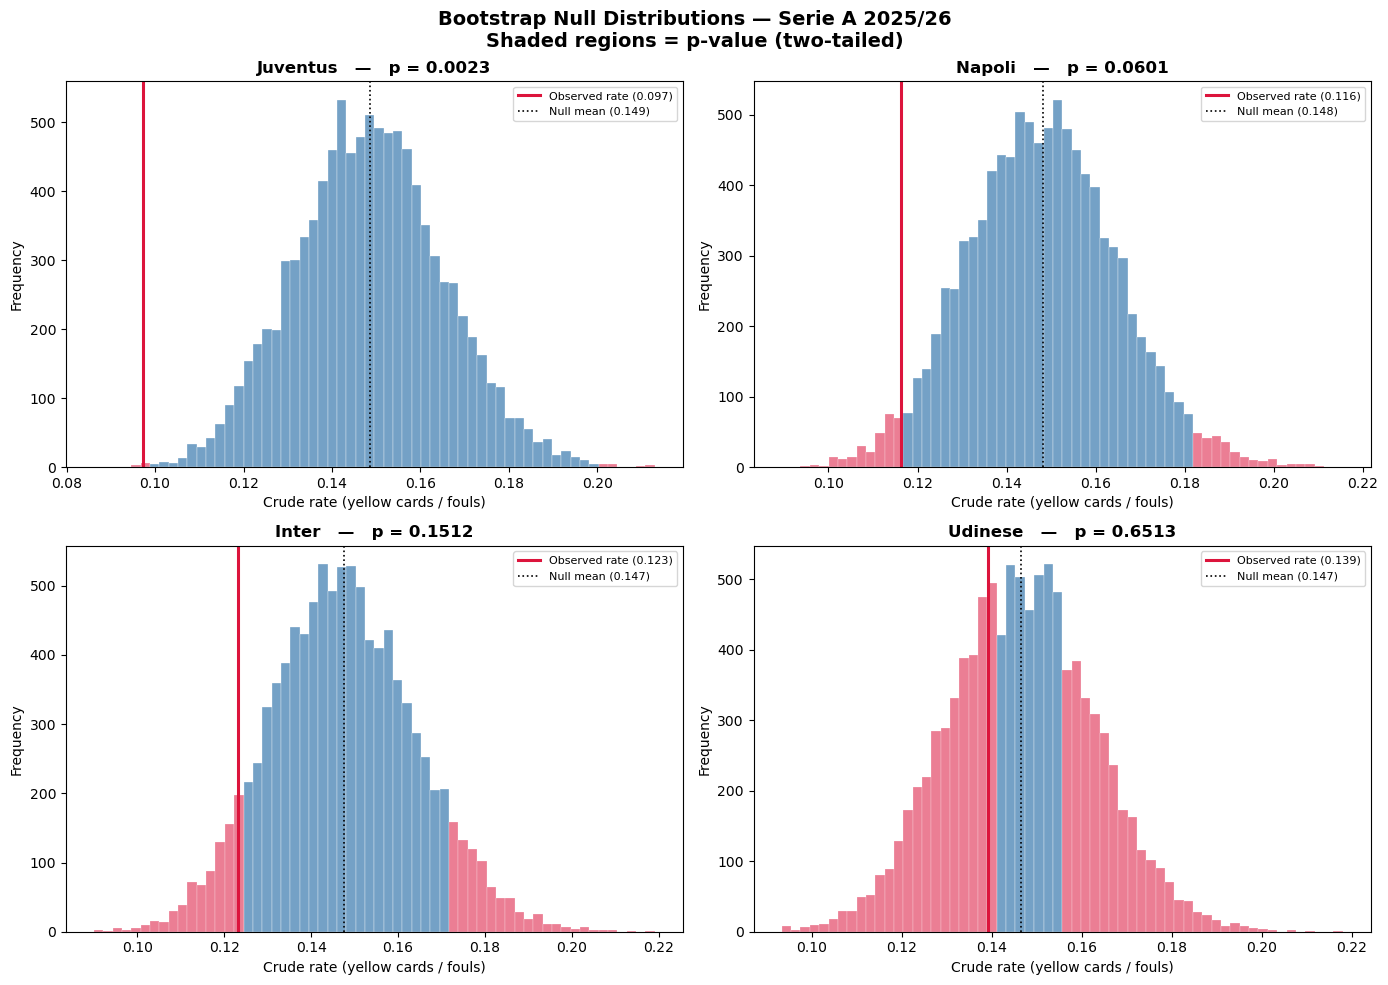

In [51]:
teams_to_plot = ['Juventus', 'Napoli', 'Inter', 'Udinese']
plot_rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, tname in zip(axes, teams_to_plot):
    t_df = test_df[test_df['team'] == tname]
    r_df = test_df[test_df['team'] != tname]
    t_m  = len(t_df)
    t_phat = t_df['yellow_cards'].sum() / t_df['fouls_committed'].sum()

    # Bootstrap null distribution
    null = np.empty(N_BOOTSTRAP)
    for i in range(N_BOOTSTRAP):
        s = r_df.sample(n=t_m, replace=True, random_state=plot_rng.integers(1e9))
        null[i] = s['yellow_cards'].sum() / s['fouls_committed'].sum()

    null_mean = null.mean()
    distance  = abs(t_phat - null_mean)
    p_val     = (np.abs(null - null_mean) >= distance).mean()

    # Plot null distribution
    counts, edges, patches = ax.hist(null, bins=60, color='steelblue', alpha=0.75,
                                     edgecolor='white', linewidth=0.3)

    # Shade tails
    lo = null_mean - distance
    hi = null_mean + distance
    for patch, left in zip(patches, edges[:-1]):
        if left <= lo or left >= hi:
            patch.set_facecolor('crimson')
            patch.set_alpha(0.55)

    # Observed rate line
    ax.axvline(t_phat, color='crimson', linewidth=2.2,
               label=f'Observed rate ({t_phat:.3f})')
    ax.axvline(null_mean, color='black', linewidth=1.2, linestyle=':',
               label=f'Null mean ({null_mean:.3f})')

    ax.set_title(f'{tname}   —   p = {p_val:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Crude rate (yellow cards / fouls)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

fig.suptitle('Bootstrap Null Distributions — Serie A 2025/26\n'
             'Shaded regions = p-value (two-tailed)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Four-team summary

| Team | $\hat{p}$ | $p_0$ | z-test | Exact binom. | Bootstrap | Mann-Whitney | $r_{rb}$ |
|---|---|---|---|---|---|---|---|
| Juventus | 0.097 | 0.149 | 0.006 | 0.004 | 0.002 | 0.002 | −0.34 |
| Napoli | 0.116 | 0.148 | 0.094 | 0.102 | 0.059 | **0.039** | −0.22 |
| Inter | 0.123 | 0.147 | 0.168 | 0.183 | 0.144 | 0.359 | −0.10 |
| Udinese | 0.139 | 0.147 | 0.666 | 0.731 | 0.651 | 0.688 | −0.04 |

Bold: the only case where a single test crosses $\alpha = 0.05$ while others do not.

**What the results say together**

The four cases form a gradient rather than a binary split. Juventus is clearly outside the expected range on all tests. Udinese is clearly inside. Inter and Napoli fall in between, with Inter showing no significant signal and Napoli showing a borderline one only on the Mann-Whitney.

**What the results do not say**

These are single-season results from an incomplete season (30 of 38 matchdays). They show that the pattern exists in the data — not that it is stable, causal, or meaningful beyond this snapshot. The next steps are:

1. **Extend across seasons**: do the same teams consistently show lower rates year after year? A persistent multi-season pattern is far stronger evidence than a single-season finding
2. **Control for confounders**: home/away balance, opponents' strength, referee assignment — all of these could partially explain the differences
3. **Multiple comparisons**: we tested four teams, not all twenty. Testing all 20 teams at $\alpha = 0.05$ would require a correction (e.g. Bonferroni or Benjamini-Hochberg) to control the false discovery rate

---

## Note to self — Permutation test as an alternative to bootstrap

*To revisit in a future project.*

During the bootstrap analysis, a question arose about why resampling is done *with* replacement rather than *without*. The short answer: resampling without replacement is a different — and equally valid — test called the **permutation test** (or randomisation test). It is worth understanding the distinction.

### Bootstrap vs permutation test

| | Bootstrap | Permutation test |
|---|---|---|
| Resampling | With replacement | Without replacement |
| Question asked | What is the sampling variability of the rate for a team drawn from this population? | Is Juventus exchangeable with any other 30-match block from the same pool? |
| Null assumption | The 570 matches are representative of a larger population | The 570 + 30 matches are all exchangeable under $H_0$ |
| p-value | Approximate (depends on B) | Exact (enumerates or approximates all permutations) |
| Best use | Estimating sampling uncertainty, confidence intervals | Testing exchangeability between two specific groups |

For the specific question *"is this team's rate different from the rest of the league?"*, the permutation test is arguably more natural: it directly tests whether Juventus's matches are distinguishable from a random draw of the same size from the non-Juventus pool. No population assumption required.

### When to prefer each

- **Bootstrap**: when you want to characterise uncertainty in an estimate, build confidence intervals, or the data is a sample from a larger population
- **Permutation test**: when you want to test exchangeability between two groups and your data *is* the full population (or you don't want to assume it represents a larger one)

In practice, with $N = 570$ and $n = 30$, both give nearly identical results here (the finite population correction is small). The choice is mainly conceptual.

### References

- Efron, B. & Hastie, T. (2016). *Computer Age Statistical Inference*, Ch. 10–11. Cambridge University Press. Free online: https://web.stanford.edu/~hastie/CASI/
- Efron, B. & Tibshirani, R. (1993). *An Introduction to the Bootstrap*. Chapman & Hall. The original reference.
- Good, P. (2005). *Permutation, Parametric, and Bootstrap Tests of Hypotheses*, 3rd ed. Springer. Directly compares the two approaches.
- Ernst, M.D. (2004). "Permutation methods: a basis for exact inference." *Statistical Science*, 19(4), 676–685. Clear conceptual treatment.